# 01 — tSNR baseline on raw noisy data

**Purpose:** measure the two things that drive every architecture decision.

1. **Baseline stSNR** — what score does the raw noisy input get against F0?
2. **τ₀.₅** — the effective temporal window; sets the 3D patch depth T.

All cells are pure measurement—no model training.

In [1]:
from load_data import load_validation_stacks

stacks = load_validation_stacks()
f0 = stacks["F0"]
f1 = stacks["F1"]
f2 = stacks["F2"]
f3 = stacks["F3"]

F0 shape=(1500, 490, 490)  F1 shape=(1500, 490, 490)
F2 shape=(1500, 490, 490)  F3 shape=(1500, 490, 490)


## Temporal ACF — finding τ₀.₅

We compute the normalized temporal ACF on 2,000 random pixels from **F0** (the clean stack) up to lag 100 frames.

### Why F0, not F1?

Poisson-Gaussian noise is temporally independent — each frame's noise is drawn fresh with no memory of the previous frame. Using F0 (clean ground-truth) reflects genuine calcium transient dynamics without noise contaminating the decay.

In [2]:
from metrics import compute_acf_and_tau

acf, tau_half = compute_acf_and_tau(f0, max_lag=100, max_pixels=2000)

τ₀.₅ (ACF=0.5 crossing) = 46 frames
Recommended patch depth T:
  τ₀.₅ = 46 → 2×τ = 92 → T = 128


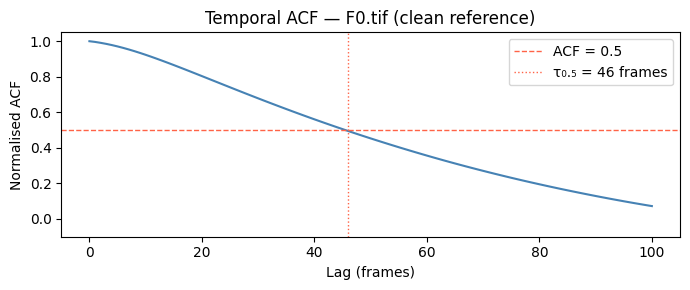

In [3]:
from plots import plot_acf

plot_acf(acf, tau_half)

## Baseline stSNR — raw noisy input vs F0

We pass each noisy stack directly with F0 as the reference, **without any denoising**. This gives us the floor score — the number a model must beat to be worth deploying.

In [4]:
from metrics import compute_baseline_stsnr

baseline_results = compute_baseline_stsnr(stacks, f0)


BASELINE stSNR — raw noisy input vs F0 (undenoised)

F1:
  stSNR = 7.274 dB (blend of sSNR and tSNR)
  sSNR  = 8.096 dB (spatial signal-to-noise)
  tSNR  = 6.452 dB (temporal signal-to-noise)

F2:
  stSNR = -0.794 dB (blend of sSNR and tSNR)
  sSNR  = -0.069 dB (spatial signal-to-noise)
  tSNR  = -1.520 dB (temporal signal-to-noise)

F3:
  stSNR = -6.639 dB (blend of sSNR and tSNR)
  sSNR  = -5.935 dB (spatial signal-to-noise)
  tSNR  = -7.343 dB (temporal signal-to-noise)



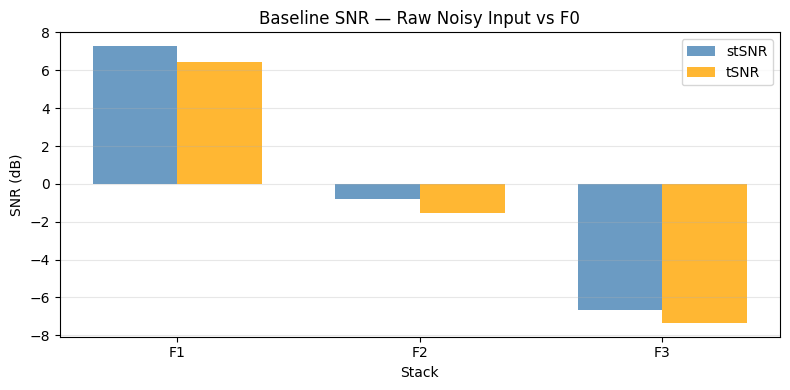

In [5]:
from plots import plot_baseline_stsnr

plot_baseline_stsnr(baseline_results)